# Cluster evaluation and visualization

Steps: load artifacts, fit/reuse KMeans clusters, compute sanity metrics (silhouette, purity/NMI/ARI), inspect clusters qualitatively (features/tags/tracks), and visualize in 2D via PCA, t-SNE, and UMAP.

## Setup and data loading
Reload cleaned dataset + weighted features from `artifacts`, keep common track IDs aligned, and build `X_main` for downstream analysis.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42

notebook_dir = Path.cwd().resolve()
project_root = notebook_dir
while not (project_root / "artifacts").exists() and project_root.parent != project_root:
    project_root = project_root.parent

artifact_dir = project_root / "artifacts"

full_df_path = artifact_dir / "full_dataset_clean.csv"
features_csv_path = artifact_dir / "features_apt_all_weighted.csv"

for path in [full_df_path, features_csv_path]:
    if not path.exists():
        raise FileNotFoundError(path)

full_df = pd.read_csv(full_df_path)
features_df = pd.read_csv(features_csv_path)

full_df["track_id"] = full_df["track_id"].astype(str)
features_df["track_id"] = features_df["track_id"].astype(str)

common_ids = pd.Index(features_df["track_id"]).intersection(full_df["track_id"])

features_df = features_df.set_index("track_id").loc[common_ids].reset_index()
full_df = full_df.set_index("track_id").loc[common_ids].reset_index()

feature_cols = [c for c in features_df.columns if c != "track_id"]
X_main = features_df[feature_cols].to_numpy(dtype=np.float32)

full_df.head()

,track_id,artists,track_name,track_genre,search_string,duration_ms,tempo,tempo_log,duration_minutes,tags_clean_text,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,lfm_playcount,lfm_listeners,log_playcount,log_listeners,log_plays_per_listener,plays_per_listener,tag_count
0,4ckoZlzQTOTEN8rhfQPbBl,Dirty Audio;Gold,No Stoppin (feat. GOLD),electronic,"No Stoppin (feat. GOLD) - Dirty Audio, Gold",160000,149.963,5.010389,2.666667,electronic usa dubstep us united state united states of america trap,0.00975,0.615,0.996,0.000142,0.0657,-0.953,0.0810,0.0797,12115.0,3312.0,9.402282,8.105609,1.538567,3.657911,7
1,3CRtbOoAP82y0VbPO5j1ft,Sasha Alex Sloan,Too Sad To Cry,electro,Too Sad To Cry - Sasha Alex Sloan,208986,120.483,4.791509,3.483100,my top song indie-pop female vocalist indie pop acoustic deezer 4-25 name variation upcoming album 2024,0.84200,0.515,0.270,0.000000,0.1140,-9.935,0.0357,0.2340,671709.0,80945.0,13.417582,11.301538,2.229836,8.298338,10
2,265SFiKBPvo5ojatV1egRk,AronChupa;Little Sis Nora,The Woodchuck Song,swedish,"The Woodchuck Song - AronChupa, Little Sis Nora",154394,126.031,4.836528,2.573233,dance electronic sweden swedish edm pop-dance club humour house hip-hop,0.01650,0.898,0.770,0.002160,0.2070,-4.970,0.3020,0.4120,228630.0,33475.0,12.339865,10.418584,2.057946,6.829873,9
3,7oQ8pTAe783QS0UwOmbHRb,Busy Signal;Mavado,Full Clip - feat. Mavado,j-dance,"Full Clip - feat. Mavado - Busy Signal, Mavado",184466,100.112,4.606290,3.074433,dancehall reggae ragga jamaican bashment busy signal jamaica caribbean all reggea,0.02610,0.726,0.692,0.000000,0.1180,-5.084,0.3340,0.5380,939.0,281.0,6.845880,5.641907,1.468251,3.341637,10
4,46Rgoqf0TIsHPudbaaqUP0,George Jones;Tammy Wynette,Did You Ever?,honky-tonk,"Did You Ever? - George Jones, Tammy Wynette",127813,74.278,4.307815,2.130217,country classic country singer-songwriter george jone americana traditional country honky tonk texa male vocalist am...,0.68500,0.613,0.295,0.000000,0.1050,-9.896,0.0303,0.8120,1262.0,453.0,7.141245,6.118097,1.331276,2.785872,10


## Fit KMeans clusters
Use number of distinct genres as `n_clusters` (as in prior notebooks) and attach labels to `full_df`.

In [2]:
from sklearn.cluster import KMeans

n_clusters = full_df["track_genre"].nunique()
print("Number of distinct genres:", n_clusters)

kmeans_main = KMeans(
    n_clusters=n_clusters,
    init="k-means++",
    n_init=10,
    random_state=RANDOM_STATE,
)

cluster_labels = kmeans_main.fit_predict(X_main)
full_df["cluster_kmeans_main"] = cluster_labels

cluster_sizes = full_df["cluster_kmeans_main"].value_counts().sort_index()
cluster_sizes.head()

Number of distinct genres: 113


cluster_kmeans_main
0    563
1    378
2    210
3    686
4    455
Name: count, dtype: int64

## Silhouette (internal cohesion/separation)
Sample up to 10k tracks for speed, compute silhouette mean and distribution.

In [3]:
from sklearn.metrics import silhouette_score, silhouette_samples

n_samples = X_main.shape[0]
max_sample = 10000

if n_samples > max_sample:
    rng = np.random.RandomState(RANDOM_STATE)
    sample_indices = rng.choice(n_samples, size=max_sample, replace=False)
else:
    sample_indices = np.arange(n_samples)

X_sample = X_main[sample_indices]
labels_sample = full_df.loc[sample_indices, "cluster_kmeans_main"].to_numpy()

silhouette_avg = silhouette_score(X_sample, labels_sample, metric="euclidean")
silhouette_vals = silhouette_samples(X_sample, labels_sample, metric="euclidean")

print(f"Silhouette score (sample of {len(sample_indices)} tracks): {silhouette_avg:.3f}")
pd.Series(silhouette_vals).describe()

Silhouette score (sample of 10000 tracks): 0.185


count    10000.000000
mean         0.185318
std          0.179566
min         -0.168065
25%          0.052274
50%          0.148782
75%          0.289617
max          0.887699
dtype: float64

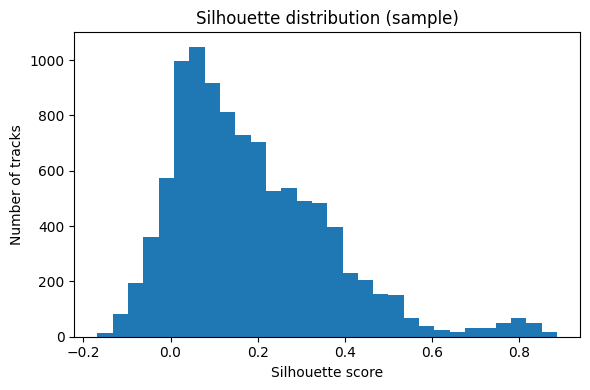

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.hist(silhouette_vals, bins=30)
plt.xlabel("Silhouette score")
plt.ylabel("Number of tracks")
plt.title("Silhouette distribution (sample)")
plt.tight_layout()
plt.show()

## Purity / NMI / ARI vs. provided genres
Compare discovered clusters to existing `track_genre` labels as a sanity check.

In [5]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

genres = full_df["track_genre"].fillna("unknown").astype(str)
clusters = full_df["cluster_kmeans_main"].to_numpy()

crosstab = pd.crosstab(clusters, genres)

majority_counts = crosstab.max(axis=1)
purity = majority_counts.sum() / len(full_df)

nmi = normalized_mutual_info_score(genres, clusters)
ari = adjusted_rand_score(genres, clusters)

print(f"Overall purity: {purity:.3f}")
print(f"NMI (clusters vs. track_genre): {nmi:.3f}")
print(f"ARI (clusters vs. track_genre): {ari:.3f}")

Overall purity: 0.469
NMI (clusters vs. track_genre): 0.584
ARI (clusters vs. track_genre): 0.229


## Cluster summaries (features + counts)
Mean feature profiles per cluster and sizes (sorted by size).

In [6]:
numeric_cols_candidate = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "valence",
    "tempo_log",
    "duration_minutes",
    "log_playcount",
    "log_listeners",
    "log_plays_per_listener",
    "tag_count",
]

numeric_cols = [c for c in numeric_cols_candidate if c in full_df.columns]

cluster_summary = (
    full_df.groupby("cluster_kmeans_main")[numeric_cols]
    .mean()
    .assign(size=lambda g: g.index.map(full_df["cluster_kmeans_main"].value_counts()))
    .sort_values("size", ascending=False)
)

cluster_summary.head(10)

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,tempo_log,duration_minutes,log_playcount,log_listeners,log_plays_per_listener,tag_count,size
cluster_kmeans_main,,,,,,,,,,,,,,,
34,0.241432,0.664733,0.721237,0.077808,0.218913,-6.464071,0.101688,0.634982,4.896312,3.469956,8.395721,7.009453,1.636231,3.348738,3527
9,0.568746,0.585543,0.441882,0.113921,0.176966,-9.975311,0.072466,0.442457,4.617523,3.343731,8.309498,6.989696,1.588203,3.265370,2879
6,0.864423,0.338119,0.206865,0.786857,0.184046,-22.554548,0.057126,0.171028,4.574769,3.281429,8.541346,7.174785,1.647837,2.459176,1335
7,0.581165,0.518583,0.450146,0.079271,0.167660,-10.264602,0.046362,0.400895,4.750812,3.688361,11.580482,9.945469,1.826089,9.094231,1040
93,0.048205,0.452756,0.871660,0.030947,0.224906,-4.917474,0.076688,0.541780,4.904230,3.155380,10.554722,8.801129,1.922652,9.090997,1033
13,0.161696,0.515575,0.723263,0.042347,0.187745,-6.342257,0.056313,0.486745,4.805111,3.689533,12.989954,11.100040,2.041390,8.771047,974
89,0.346328,0.584064,0.581813,0.093311,0.180611,-7.823925,0.059530,0.468303,4.785544,3.432179,12.429945,10.540818,2.040593,8.604013,947
32,0.260014,0.712948,0.658000,0.014004,0.188626,-7.195045,0.196364,0.537125,4.742277,3.446415,11.138044,9.173270,2.107518,7.464883,897
8,0.125934,0.691880,0.764078,0.051635,0.194701,-5.980182,0.079117,0.623676,4.808952,3.507853,11.359330,9.676696,1.873339,8.296343,793


## Tags and representative tracks
Top tags per cluster (if available) and a few nearest-to-centroid tracks for qualitative inspection.

In [7]:
from collections import Counter

def top_tags_for_cluster(cluster_id, top_n=10):
    if "tags_clean_text" not in full_df.columns:
        return []
    mask = full_df["cluster_kmeans_main"] == cluster_id
    tags_series = full_df.loc[mask, "tags_clean_text"].fillna("")
    counter = Counter()
    for s in tags_series:
        if not s:
            continue
        for t in s.split():
            counter[t] += 1
    return counter.most_common(top_n)

first_cluster = int(cluster_summary.index[0])
top_tags_for_cluster(first_cluster, top_n=10)

[('pop', 557),
 ('rock', 471),
 ('brazilian', 432),
 ('brazil', 380),
 ('vocalist', 318),
 ('brasil', 292),
 ('electronic', 243),
 ('female', 207),
 ('all', 199),
 ('american', 199)]

In [8]:
from sklearn.metrics import pairwise_distances

def representative_tracks(cluster_id, top_n=5):
    mask = full_df["cluster_kmeans_main"] == cluster_id
    indices = np.where(mask.to_numpy())[0]
    if len(indices) == 0:
        return full_df.iloc[[]]

    center = kmeans_main.cluster_centers_[cluster_id]
    X_cluster = X_main[indices]
    dists = pairwise_distances(X_cluster, center.reshape(1, -1), metric="euclidean").ravel()
    order = np.argsort(dists)[:top_n]
    chosen = indices[order]
    return full_df.loc[chosen, ["track_id", "artists", "track_name", "track_genre"]]

representative_tracks(first_cluster, top_n=5)

,track_id,artists,track_name,track_genre
28630,2uyYcVToGd0P3twslT6Qzn,DJ Black Rock,GDFR (Going Down for Real),kids
26620,0U7SRbyBhkdXdulXr3veKQ,Kevi Jonny,Aquele Story,forro
52645,6Eo1tU0Zw7Bgw3cPtVKxRX,Balek,112,party
39486,11CrYElJH7l26yy5Tb5Ihy,Matadoria,Vettam,malay
48268,6JilFqhtGTaEdKH6EYf10j,Kevi Jonny,Arranhão,forro


In [9]:
def describe_cluster(cluster_id, top_n_tags=10, top_n_tracks=5):
    if "cluster_kmeans_main" not in full_df.columns:
        raise ValueError("cluster_kmeans_main not found; run clustering cell first.")

    mask = full_df["cluster_kmeans_main"] == cluster_id
    size = int(mask.sum())
    if size == 0:
        print(f"Cluster {cluster_id} has no rows.")
        return

    genres = full_df.loc[mask, "track_genre"].value_counts().head(5)
    means = full_df.loc[mask, numeric_cols].mean() if numeric_cols else pd.Series(dtype=float)

    print(f"Cluster {cluster_id}")
    print(f"Size: {size}")
    print("Top genres:")
    print(genres)
    print("Mean feature profile:")
    print(means.round(3))
    print("Top tags:")
    print(top_tags_for_cluster(cluster_id, top_n=top_n_tags))
    print("Representative tracks:")
    display(representative_tracks(cluster_id, top_n=top_n_tracks))

# fall back if cluster_summary is missing
if "cluster_summary" not in globals():
    cluster_summary = (
        full_df.groupby("cluster_kmeans_main")[numeric_cols]
        .mean()
        .assign(size=lambda g: g.index.map(full_df["cluster_kmeans_main"].value_counts()))
        .sort_values("size", ascending=False)
    )

cluster_ids = list(cluster_summary.index[:5])
for cid in cluster_ids:
    describe_cluster(int(cid))
    print("-" * 60)


Cluster 34
Size: 3527
Top genres:
track_genre
kids        296
forro       201
party       153
children    148
malay       138
Name: count, dtype: int64
Mean feature profile:
acousticness              0.241
danceability              0.665
energy                    0.721
instrumentalness          0.078
liveness                  0.219
loudness                 -6.464
speechiness               0.102
valence                   0.635
tempo_log                 4.896
duration_minutes          3.470
log_playcount             8.396
log_listeners             7.009
log_plays_per_listener    1.636
tag_count                 3.349
dtype: float64
Top tags:
[('pop', 557), ('rock', 471), ('brazilian', 432), ('brazil', 380), ('vocalist', 318), ('brasil', 292), ('electronic', 243), ('female', 207), ('all', 199), ('american', 199)]
Representative tracks:


,track_id,artists,track_name,track_genre
28630,2uyYcVToGd0P3twslT6Qzn,DJ Black Rock,GDFR (Going Down for Real),kids
26620,0U7SRbyBhkdXdulXr3veKQ,Kevi Jonny,Aquele Story,forro
52645,6Eo1tU0Zw7Bgw3cPtVKxRX,Balek,112,party
39486,11CrYElJH7l26yy5Tb5Ihy,Matadoria,Vettam,malay
48268,6JilFqhtGTaEdKH6EYf10j,Kevi Jonny,Arranhão,forro


------------------------------------------------------------
Cluster 9
Size: 2879
Top genres:
track_genre
study          226
malay          186
honky-tonk     144
disney         128
rock-n-roll    120
Name: count, dtype: int64
Mean feature profile:
acousticness              0.569
danceability              0.586
energy                    0.442
instrumentalness          0.114
liveness                  0.177
loudness                 -9.975
speechiness               0.072
valence                   0.442
tempo_log                 4.618
duration_minutes          3.344
log_playcount             8.309
log_listeners             6.990
log_plays_per_listener    1.588
tag_count                 3.265
dtype: float64
Top tags:
[('pop', 573), ('country', 392), ('vocalist', 364), ('rock', 281), ('singer-songwriter', 253), ('male', 232), ('female', 201), ('all', 181), ('american', 170), ('brazilian', 151)]
Representative tracks:


,track_id,artists,track_name,track_genre
32919,3RDDPTFuikYlu0A4OXCCkl,Nicolas Candido,Hoje Caminhei,mpb
16945,1IF1IpJ8SnBDgHO5Nig0pD,"Francisco, el Hombre",O TEMPO É SUA MORADA :: celebrar,mpb
33243,5qG6pu4Vq9f7wB0NAso4UN,King Shubh;King,Ghumshudaa (Lofi Flip) [feat. King],indian
33350,4tm6TQQGoUdOfCYh639No1,Talita Barreto,Ele É,groove
4595,1z9GHAYy5cSzeh4rRnafSN,Sonia Rivas,Con Tu Misma Moneda,rock-n-roll


------------------------------------------------------------
Cluster 6
Size: 1335
Top genres:
track_genre
sleep        355
disney       137
piano        122
classical    106
study        101
Name: count, dtype: int64
Mean feature profile:
acousticness               0.864
danceability               0.338
energy                     0.207
instrumentalness           0.787
liveness                   0.184
loudness                 -22.555
speechiness                0.057
valence                    0.171
tempo_log                  4.575
duration_minutes           3.281
log_playcount              8.541
log_listeners              7.175
log_plays_per_listener     1.648
tag_count                  2.459
dtype: float64
Top tags:
[('ambient', 238), ('classical', 150), ('electronic', 142), ('experimental', 85), ('american', 73), ('noise', 71), ('composer', 67), ('all', 63), ('drone', 56), ('downtempo', 54)]
Representative tracks:


...

------------------------------------------------------------
Cluster 7
Size: 1040
Top genres:
track_genre
acoustic    327
folk        106
british      95
ambient      79
afrobeat     46
Name: count, dtype: int64
Mean feature profile:
acousticness               0.581
danceability               0.519
energy                     0.450
instrumentalness           0.079
liveness                   0.168
loudness                 -10.265
speechiness                0.046
valence                    0.401
tempo_log                  4.751
duration_minutes           3.688
log_playcount             11.580
log_listeners              9.945
log_plays_per_listener     1.826
tag_count                  9.094
dtype: float64
Top tags:
[('folk', 1904), ('indie', 919), ('singer-songwriter', 698), ('acoustic', 677), ('rock', 643), ('vocalist', 531), ('pop', 484), ('male', 326), ('alternative', 293), ('american', 268)]
Representative tracks:


,track_id,artists,track_name,track_genre
36586,3avWV9e8Z0o6RMMHh9ysZF,Bhoomi,Lal Paharir Deshe Ja,indie-pop
19381,4yyg2J2uXOjCtCyT64984C,Lord Huron,Ends of the Earth,folk
469,34f6sZPLPVsGwgBOrW3iLu,Roo Panes,Land Of The Living,british
33327,2ixsaeFioXJmMgkkbd4uj1,George Ezra,Budapest,folk
31808,3EgC9peIAOtKROIHsRqVVZ,Robert John Ardiff,People Talking,dub


------------------------------------------------------------
Cluster 93
Size: 1033
Top genres:
track_genre
power-pop    245
punk-rock    175
hardcore     119
emo           99
punk          61
Name: count, dtype: int64
Mean feature profile:
acousticness               0.048
danceability               0.453
energy                     0.872
instrumentalness           0.031
liveness                   0.225
loudness                  -4.917
speechiness                0.077
valence                    0.542
tempo_log                  4.904
duration_minutes           3.155
log_playcount             10.555
log_listeners              8.801
log_plays_per_listener     1.923
tag_count                  9.091
dtype: float64
Top tags:
[('punk', 3289), ('rock', 2113), ('pop', 855), ('hardcore', 471), ('alternative', 405), ('american', 331), ('melodic', 280), ('pop-punk', 239), ('emo', 149), ('indie', 145)]
Representative tracks:


,track_id,artists,track_name,track_genre
37235,6yOr6vYhgHmYjhrmmlfd6s,Rybičky 48,Jdi domů Ivane,punk-rock
9984,4JAtDXVF8f5OgCkz1vEAfU,Rybičky 48,Muži,punk-rock
43840,5pcfYLrIw2w5TmmDBkKDkB,Rybičky 48,Bohém zapomenutý dítě,punk-rock
43573,5hRYqAIsLf6I7zRP3wOoLw,Tronic,Fenix,punk-rock
18310,1CrCjB0ihP0OBPMHYwviF0,Nekromantix,Dead Girls Don't Cry,psych-rock


------------------------------------------------------------


## PCA (fast linear view)
Project a sample (≤20k) to 2D via PCA and color by cluster to see broad separation patterns.

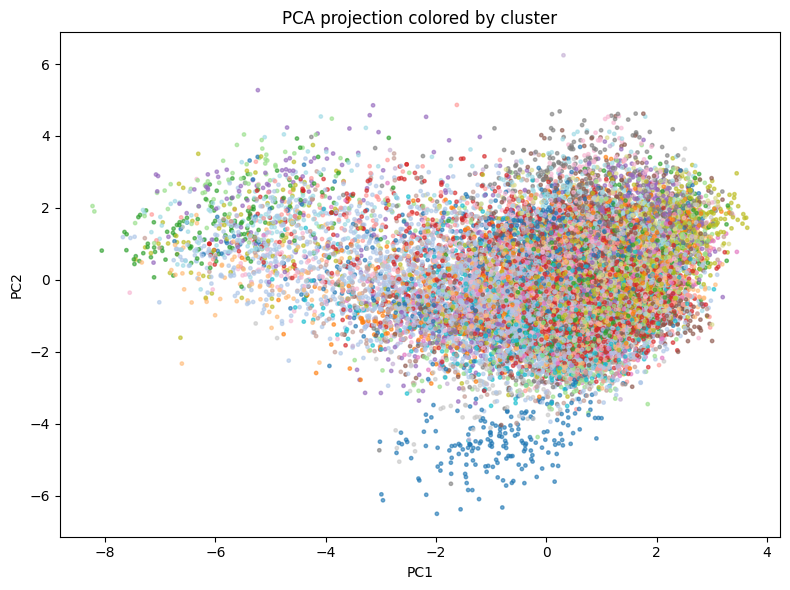

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

n_samples = X_main.shape[0]
max_sample = 20000

if n_samples > max_sample:
    rng = np.random.RandomState(RANDOM_STATE)
    vis_indices = rng.choice(n_samples, size=max_sample, replace=False)
else:
    vis_indices = np.arange(n_samples)

X_vis = X_main[vis_indices]
clusters_vis = full_df.loc[vis_indices, "cluster_kmeans_main"].to_numpy()

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_vis)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_vis, s=6, alpha=0.6, cmap="tab20")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection colored by cluster")
plt.tight_layout()
plt.show()

## t-SNE (nonlinear local structure)
Sample up to 5k, choose a safe perplexity relative to sample size, and plot clusters for finer-grained separation.

t-SNE sample size: 5000, perplexity: 30
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.000s...
[t-SNE] Computed neighbors for 5000 samples in 0.149s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 2.582005
[t-SNE] KL divergence after 250 iterations with early exaggeration: 84.660553
[t-SNE] KL divergence after 1000 iterations: 1.115829


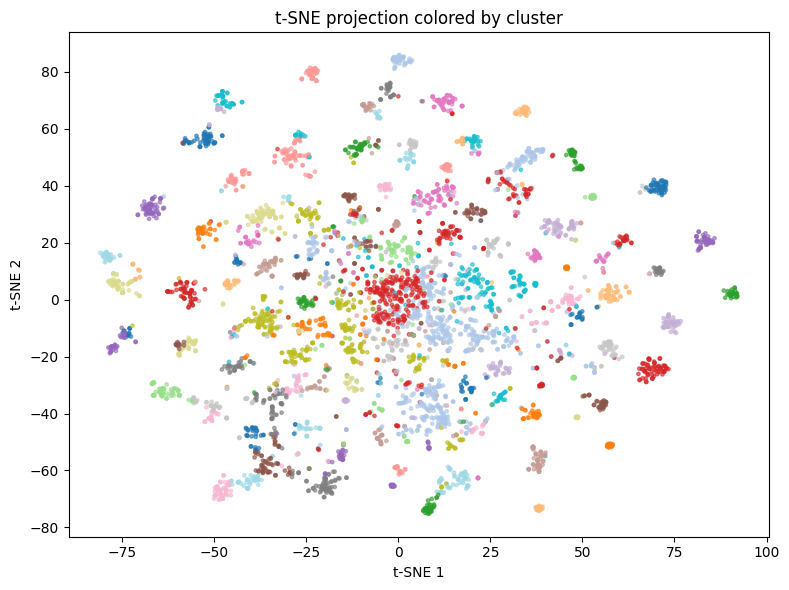

In [11]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

max_tsne = 5000

if n_samples > max_tsne:
    rng = np.random.RandomState(RANDOM_STATE)
    tsne_indices = rng.choice(n_samples, size=max_tsne, replace=False)
else:
    tsne_indices = np.arange(n_samples)

X_tsne_in = X_main[tsne_indices]
clusters_tsne = full_df.loc[tsne_indices, "cluster_kmeans_main"].to_numpy()

n_tsne = len(tsne_indices)
if n_tsne <= 10:
    raise ValueError(f"Not enough samples for t-SNE (got {n_tsne})")
perplexity = min(30, max(5, n_tsne // 3))
if perplexity >= n_tsne:
    perplexity = max(5, n_tsne - 1)

print(f"t-SNE sample size: {n_tsne}, perplexity: {perplexity}")

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate=200,
    metric="euclidean",
    init="random",
    random_state=RANDOM_STATE,
    verbose=1,
)

X_tsne = tsne.fit_transform(X_tsne_in)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters_tsne, s=6, alpha=0.6, cmap="tab20")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE projection colored by cluster")
plt.tight_layout()
plt.show()

## UMAP (nonlinear global+local)
Try UMAP on a sample to compare with t-SNE. If `umap-learn` is missing, a friendly message will appear.

In [13]:
try:
    import umap
except ImportError:
    print("umap-learn is not installed; install with `pip install umap-learn` to run this cell.")
else:
    max_umap = 10000
    if n_samples > max_umap:
        rng = np.random.RandomState(RANDOM_STATE)
        umap_indices = rng.choice(n_samples, size=max_umap, replace=False)
    else:
        umap_indices = np.arange(n_samples)

    X_umap_in = X_main[umap_indices]
    clusters_umap = full_df.loc[umap_indices, "cluster_kmeans_main"].to_numpy()

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=25,
        min_dist=0.15,
        metric="euclidean",
        random_state=RANDOM_STATE,
    )
    X_umap = reducer.fit_transform(X_umap_in)

    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 6))
    plt.scatter(X_umap[:, 0], X_umap[:, 1], c=clusters_umap, s=6, alpha=0.6, cmap="tab20")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title("UMAP projection colored by cluster")
    plt.tight_layout()
    plt.show()

umap-learn is not installed; install with `pip install umap-learn` to run this cell.


## Conclusion (fill after running)
- Note silhouette and purity/NMI/ARI values and whether they indicate clean separation.
- Describe a few clusters (genres, moods, key features) using the summaries and representative tracks.
- Compare PCA vs. t-SNE vs. UMAP: which shows clearer separation, which clusters overlap.
- Call out any weak/mixed clusters and possible follow-ups (e.g., tune `n_clusters`, reweight features).

Cluster takeaways from your runs:

Silhouette ~0.185 on 10k sample: weak/moderate separation; many points sit near boundaries.

Genre alignment: purity 0.469, NMI 0.584, ARI 0.229 — clusters capture some genre signal but are mixed.

Example cluster (id 34, size 3527) skews high-danceability/energy, mid valence, Brazilian-heavy tags (“pop/rock/brazilian/brasil”), and top genres kids/forro/party; representatives span pop-party/K-pop/forro, so it’s broad rather than tight.

t-SNE (5k, perplexity 30) ran; use the plot to see overlap—expect some blending given the metrics.

UMAP didn’t run (umap-learn missing); install and rerun to compare layouts.


Suggested next steps: (1) tighten clusters—try fewer clusters or rebalance feature weights; (2) inspect other large clusters for specificity; (3) rerun with UMAP to see if structure clarifies.

## Subjective evaluation & fun checks

Traditional metrics only go so far; recommenders are judged by taste. This section adds some lightweight, subjective sanity checks without external APIs (Spotify API is not used here). Goals:
- Spot same-artist bias vs. variety.
- See if recs stay within a genre/mood.
- Manually eyeball a few seed tracks and their neighbors.
- (Optional) A/B later against Spotify or Last.fm if you hook up their APIs.

In [16]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

# Build a quick cosine-KNN recommender on the feature space (reuse if already built)
if 'knn_recs' not in globals():
    knn_recs = NearestNeighbors(metric="cosine", algorithm="brute")
    knn_recs.fit(X_main)


def primary_artist(artists: str) -> str:
    if not isinstance(artists, str):
        return ""
    return artists.split(";")[0].strip().lower()


def find_index(title: str, artist: str | None = None):
    title_mask = full_df["track_name"].str.lower().fillna("") == title.lower()
    if artist:
        artist_mask = full_df["artists"].str.lower().fillna("").str.contains(artist.lower())
    else:
        artist_mask = True
    mask = title_mask & artist_mask
    if not mask.any():
        # fallback: partial title match
        title_mask = full_df["track_name"].str.lower().fillna("").str.contains(title.lower())
        mask = title_mask & artist_mask
    return mask[mask].index[0] if mask.any() else None


def recommend_by_idx(idx: int, k: int = 10):
    distances, indices = knn_recs.kneighbors(X_main[idx : idx + 1], n_neighbors=k + 1)
    recs = full_df.iloc[indices[0][1:]].copy()
    recs["cosine"] = distances[0][1:]
    return recs

seed_candidates = [
    ("HUMBLE.", "Kendrick Lamar"),
    ("bad guy", "Billie Eilish"),
    ("Shape of You", "Ed Sheeran"),
    ("Blinding Lights", "The Weeknd"),
    ("Levitating", "Dua Lipa"),
]

seed_indices = []
for title, artist in seed_candidates:
    idx = find_index(title, artist)
    if idx is not None:
        seed_indices.append(idx)
        continue

# Fallback: sample a few random seeds if none of the above exist
if not seed_indices:
    rng = np.random.default_rng(42)
    seed_indices = rng.choice(len(full_df), size=5, replace=False).tolist()

summary_rows = []
for idx in seed_indices:
    recs = recommend_by_idx(idx, k=10)
    seed_primary = primary_artist(full_df.loc[idx, "artists"])
    seed_genre = full_df.loc[idx, "track_genre"]
    recs_primary = recs["artists"].str.split(";").str[0].str.strip().str.lower()
    same_primary = (recs_primary == seed_primary).mean()
    contains_seed = recs["artists"].str.lower().str.contains(seed_primary).mean() if seed_primary else 0.0
    same_genre = (recs["track_genre"] == seed_genre).mean()
    summary_rows.append(
        {
            "seed_track": full_df.loc[idx, "track_name"],
            "seed_artist": full_df.loc[idx, "artists"],
            "seed_genre": seed_genre,
            "same_primary_artist_share": round(float(same_primary), 3),
            "any_seed_artist_share": round(float(contains_seed), 3),
            "same_genre_share": round(float(same_genre), 3),
        }
    )

summary_df = pd.DataFrame(summary_rows)
print("Quick same-artist / genre bias check (per seed):")
display(summary_df)

# Show a few short recommendation lists
print("Sample recommendations (top 5) for first few seeds:")
for idx in seed_indices[:3]:
    seed_row = full_df.loc[idx]
    print(f"Seed: {seed_row['track_name']} — {seed_row['artists']} (genre: {seed_row['track_genre']})")
    recs = recommend_by_idx(idx, k=5)
    display(recs[["track_name", "artists", "track_genre", "cosine"]])
    print("-")

Quick same-artist / genre bias check (per seed):


,seed_track,seed_artist,seed_genre,same_primary_artist_share,any_seed_artist_share,same_genre_share
0,HUMBLE.,Kendrick Lamar,hip-hop,0.1,0.1,0.5
1,bad guy (with Justin Bieber),Billie Eilish;Justin Bieber,electro,0.2,0.2,0.2
2,Shape of You,Ed Sheeran,pop,0.0,0.0,0.0
3,Levitating (feat. DaBaby),Dua Lipa;DaBaby,dance,0.0,0.0,0.1


Sample recommendations (top 5) for first few seeds:
Seed: HUMBLE. — Kendrick Lamar (genre: hip-hop)


,track_name,artists,track_genre,cosine
39710,R.I.P.,Playboi Carti,hip-hop,0.026203
20031,SICKO MODE,Travis Scott,hip-hop,0.037620
37547,INDUSTRY BABY (feat. Jack Harlow),Lil Nas X;Jack Harlow,hip-hop,0.039090
53932,Pass,Nizi19;Karamel19,german,0.064460
2577,Best Friend,Young Thug,hip-hop,0.074997


-
Seed: bad guy (with Justin Bieber) — Billie Eilish;Justin Bieber (genre: electro)


,track_name,artists,track_genre,cosine
31578,Happier Than Ever - Edit,Billie Eilish,electro,0.144632
27827,my boy,Billie Eilish,electro,0.224425
47365,Deixa Eu Te Amar,DUDA BEAT,mpb,0.252128
40651,Mujer Contra Mujer,Javiera Mena,electronic,0.269344
21076,Bolo de Rolo,DUDA BEAT,funk,0.272197


-
Seed: Shape of You — Ed Sheeran (genre: pop)


,track_name,artists,track_genre,cosine
47316,Rockabye (feat. Sean Paul & Anne-Marie),Clean Bandit;Sean Paul;Anne-Marie,dance,0.084398
30640,Lean On,Major Lazer;MØ;DJ Snake,dance,0.230167
15811,Get Busy,Sean Paul,dancehall,0.260423
39151,Tempted To Touch,Rupee,dancehall,0.262428
17415,Kiss and Make Up,Dua Lipa;BLACKPINK,dance,0.286993


-


### Notes on this subjective check
- If you see very high `same_primary_artist_share`, the model is strongly favoring repeats; depending on your goal that can be good (deep cuts) or bad (lack of discovery).
- `same_genre_share` hints at how tight the neighborhood is; low values may mean blending across genres/moods.
- To compare with Spotify later, you can plug their API and A/B the top-5 lists; here we stay offline.
- You can swap the `seed_candidates` to your own favorites and rerun for a vibe check.

### Aggregate bias metrics
Run the same-artist/genre checks over many random seeds to get average tendencies (no external APIs).

In [17]:
import numpy as np
import pandas as pd

if 'recommend_by_idx' not in globals():
    raise RuntimeError("Run the fun-check recommender cell above first.")

rng = np.random.default_rng(123)
num_seeds = 100
k = 10

seed_indices = rng.choice(len(full_df), size=min(num_seeds, len(full_df)), replace=False)
rows = []
for idx in seed_indices:
    recs = recommend_by_idx(idx, k=k)
    seed_primary = primary_artist(full_df.loc[idx, "artists"])
    seed_genre = full_df.loc[idx, "track_genre"]
    recs_primary = recs["artists"].str.split(";").str[0].str.strip().str.lower()
    same_primary = (recs_primary == seed_primary).mean()
    any_seed = recs["artists"].str.lower().str.contains(seed_primary).mean() if seed_primary else 0.0
    same_genre = (recs["track_genre"] == seed_genre).mean()
    rows.append(
        {
            "seed_track": full_df.loc[idx, "track_name"],
            "seed_artist": full_df.loc[idx, "artists"],
            "seed_genre": seed_genre,
            "same_primary_artist_share": float(same_primary),
            "any_seed_artist_share": float(any_seed),
            "same_genre_share": float(same_genre),
        }
    )

agg_df = pd.DataFrame(rows)
print(f"Aggregated over {len(agg_df)} seeds (k={k} neighbors per seed):")

summary = agg_df[["same_primary_artist_share", "any_seed_artist_share", "same_genre_share"]].agg(['mean','std','min','max'])
display(summary)

print("Quantiles (0.1, 0.5, 0.9):")
display(agg_df[["same_primary_artist_share", "any_seed_artist_share", "same_genre_share"]].quantile([0.1,0.5,0.9]))


Aggregated over 100 seeds (k=10 neighbors per seed):


,same_primary_artist_share,any_seed_artist_share,same_genre_share
mean,0.494000,0.494000,0.714000
std,0.384765,0.384765,0.352199
min,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000


Quantiles (0.1, 0.5, 0.9):


,same_primary_artist_share,any_seed_artist_share,same_genre_share
0.1,0.0,0.0,0.1
0.5,0.4,0.4,0.9
0.9,1.0,1.0,1.0
